# Notebook 1 — Human Vital Signs Risk Classification

## Import Libraries

In [91]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier
print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## Data Path

In [92]:
DATA_PATH = "/kaggle/input/datasets/engrarri21/human-vital-signs/Human_vital_signs_R.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (25493, 7)


,Unnamed: 0,Time (s),HR (BPM),RESP (BPM),SpO2 (%),TEMP (*C),OUTPUT
0,0,0,94.0,21.0,97.0,36.2,Normal
1,1,1,94.0,25.0,97.0,36.2,Normal
2,2,2,101.0,25.0,93.0,38.0,Abnormal
3,3,3,55.0,11.0,100.0,35.0,Abnormal
4,4,4,93.0,26.0,95.0,37.0,Normal


## Change Name 

In [93]:
df = df.rename(columns={
    "Unnamed: 0": "Record_ID",
    "Time (s)": "Time",
    " HR (BPM)": "Heart_Rate",
    " RESP (BPM)": "Respiratory_Rate",
    " SpO2 (%)": "SpO2",
    "TEMP (*C)": "Temperature",
    "OUTPUT": "Risk_Category"
})
print(df.columns.tolist())

['Record_ID', 'Time', 'Heart_Rate', 'Respiratory_Rate', 'SpO2', 'Temperature', 'Risk_Category']


## 1. Data Understanding

In [94]:
print("Columns:")
display(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

print("\nSummary:")
display(df.describe(include="all").T)

Columns:


['Record_ID',
 'Time',
 'Heart_Rate',
 'Respiratory_Rate',
 'SpO2',
 'Temperature',
 'Risk_Category']


Data types:


,dtype
Record_ID,int64
Time,int64
Heart_Rate,float64
Respiratory_Rate,float64
SpO2,float64
Temperature,float64
Risk_Category,object



Missing values:


,missing
Record_ID,0
Time,0
Heart_Rate,5
Respiratory_Rate,147
SpO2,127
Temperature,0
Risk_Category,0



Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Record_ID,25493.0,NaN,NaN,NaN,240.0,138.855163,0.0,120.0,240.0,360.0,480.0
Time,25493.0,NaN,NaN,NaN,239.981132,138.85523,-1.0,120.0,240.0,360.0,480.0
Heart_Rate,25488.0,NaN,NaN,NaN,89.127943,13.220448,44.0,81.0,89.0,95.0,139.0
Respiratory_Rate,25346.0,NaN,NaN,NaN,17.640496,3.589381,0.0,16.0,18.0,20.0,34.0
SpO2,25366.0,NaN,NaN,NaN,96.716471,3.323381,83.0,95.0,97.0,99.0,111.0
Temperature,25493.0,NaN,NaN,NaN,37.590123,5.211265,21.0,34.0,38.0,41.0,49.0
Risk_Category,25493,2,Abnormal,19702,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Visualization output 

Target distribution:


,count
Risk_Category,
Abnormal,19702
Normal,5791


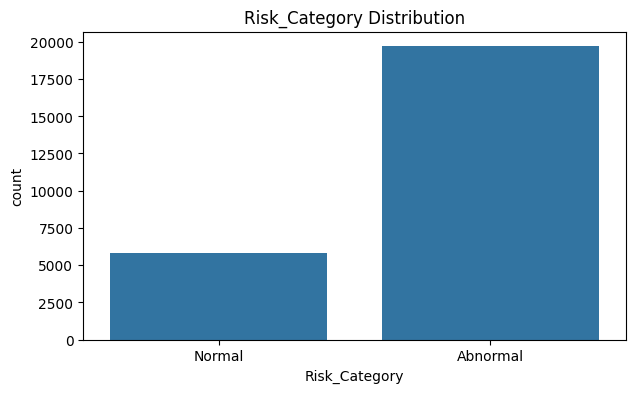

Class percentages:


,percentage
Risk_Category,
Abnormal,77.28
Normal,22.72


In [95]:
print("Target distribution:")
display(df["Risk_Category"].value_counts().to_frame("count"))

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Risk_Category")
plt.title("Risk_Category Distribution")
plt.show()

print("Class percentages:")
display((df["Risk_Category"].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))

## 2. Data Cleaning


In [129]:
## duplicate
# Check exact duplicates first
exact_duplicates = df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicate rows:", df.shape)

Exact duplicate rows: 0
Shape after removing duplicate rows: (25477, 7)


In [130]:
# Check missing values
null_count = df.isnull().sum()

display(null_count.to_frame("Null_Count"))
null_percentage = (df.isnull().sum() / len(df)) * 100

null_summary = pd.DataFrame({
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": null_percentage
})

display(null_summary)

,Null_Count
Record_ID,0
Time,0
Heart_Rate,5
Respiratory_Rate,147
SpO2,127
Temperature,0
Risk_Category,0


,Null_Count,Null_Percentage
Record_ID,0,0.000000
Time,0,0.000000
Heart_Rate,5,0.019626
Respiratory_Rate,147,0.576991
SpO2,127,0.498489
Temperature,0,0.000000
Risk_Category,0,0.000000


## 3. EDA

## Target Analysis

Risk_Category
Abnormal    19698
Normal       5779
Name: count, dtype: int64
Risk_Category
Abnormal    77.316796
Normal      22.683204
Name: proportion, dtype: float64


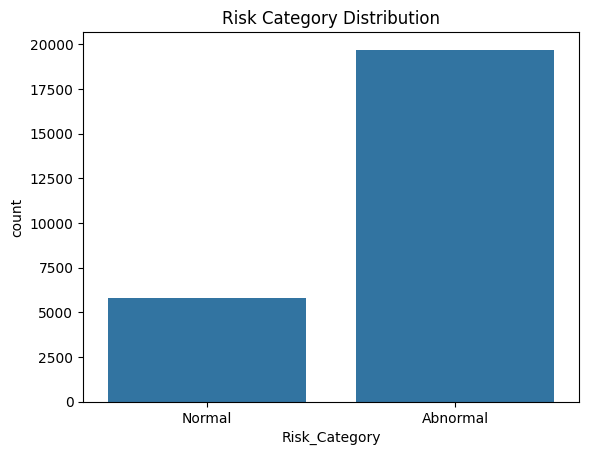

In [98]:
print(df["Risk_Category"].value_counts())
print(df["Risk_Category"].value_counts(normalize=True) * 100)
sns.countplot(data=df, x="Risk_Category")
plt.title("Risk Category Distribution")
plt.show()

## Numerical Features Distribution

In [99]:
import plotly.express as px
from plotly.subplots import make_subplots

features = [
    "Heart_Rate",
    "Respiratory_Rate",
    "SpO2",
    "Temperature"
]

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=features
)

for i, col in enumerate(features):
    row = i // 2 + 1
    col_num = i % 2 + 1

    temp_fig = px.histogram(df, x=col)

    for trace in temp_fig.data:
        fig.add_trace(trace, row=row, col=col_num)

fig.update_layout(
    title="Distribution of Vital Signs",
    height=700,
    width=1000,
    showlegend=False
)

fig.show()

## Outliers Detection

In [100]:
features = [
    "Heart_Rate",
    "Respiratory_Rate",
    "SpO2",
    "Temperature"
]

fig = px.box(
    df,
    y=features,
    title="Outliers Detection - Vital Signs"
)

fig.show()

## Features vs Target

In [101]:
import plotly.express as px
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1,
    cols=len(features),
    subplot_titles=features
)

for i, col in enumerate(features, 1):
    temp_fig = px.box(
        df,
        x="Risk_Category",
        y=col,
        color="Risk_Category"
    )

    for trace in temp_fig.data:
        fig.add_trace(trace, row=1, col=i)

fig.update_layout(
    title="Vital Signs vs Risk Category",
    height=500,
    width=1400,
    showlegend=False
)

fig.show()

## Check Outliers

In [102]:
features = [
    "Heart_Rate",
    "Respiratory_Rate",
    "SpO2",
    "Temperature"
]

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Heart_Rate: 1188 outliers
Respiratory_Rate: 548 outliers
SpO2: 989 outliers
Temperature: 224 outliers


## Correlation Analysis

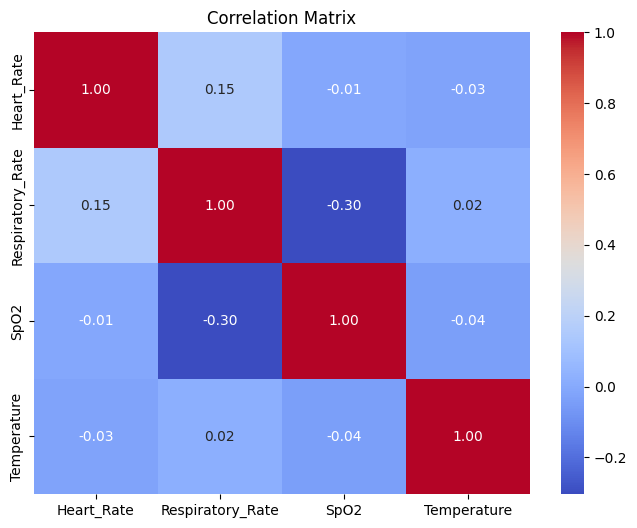

In [103]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## 4.Prepare X and Y

In [131]:
features = [
    "Heart_Rate",
    "Respiratory_Rate",
    "SpO2",
    "Temperature"
]

target = "Risk_Category"
X = df[features]
y = df[target]

## LabelEncoder

In [132]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [133]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny values:")
print(y[:10])

X shape: (25477, 4)
y shape: (25477,)

X columns:
['Heart_Rate', 'Respiratory_Rate', 'SpO2', 'Temperature']

y values:
[1 1 0 0 1 1 1 1 1 1]


## 5. Train / Test Split


In [134]:
from sklearn.model_selection import GroupShuffleSplit

X = df[features]
y = df["Risk_Category"]
groups = df["Record_ID"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

In [135]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train groups:", groups_train.nunique())
print("Test groups:", groups_test.nunique())

print(
    "Common groups:",
    len(set(groups_train) & set(groups_test))
)

Train shape: (20338, 4)
Test shape: (5139, 4)
Train groups: 384
Test groups: 97
Common groups: 0


In [136]:
print(pd.Series(y_train).value_counts(normalize=True))
print(pd.Series(y_test).value_counts(normalize=True))

Risk_Category
Abnormal    0.773527
Normal      0.226473
Name: proportion, dtype: float64
Risk_Category
Abnormal    0.771745
Normal      0.228255
Name: proportion, dtype: float64


In [137]:
print("Train distribution:")
print(np.unique(y_train, return_counts=True))

print("\nTest distribution:")
print(np.unique(y_test, return_counts=True))

Train distribution:
(array(['Abnormal', 'Normal'], dtype=object), array([15732,  4606]))

Test distribution:
(array(['Abnormal', 'Normal'], dtype=object), array([3966, 1173]))


## 6. Preprocessing

In [138]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), features)
])

In [139]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

print(le.classes_)

['Abnormal' 'Normal']


In [140]:
y_train_xgb = y_train.map({
    "Normal": 0,
    "Abnormal": 1
})

y_test_xgb = y_test.map({
    "Normal": 0,
    "Abnormal": 1
})

## Calculate XGBoost Class Weight

In [141]:

class_counts = y_train.value_counts()

negative = class_counts["Normal"]
positive = class_counts["Abnormal"]

scale_pos_weight = negative / positive

print("Normal:", negative)
print("Abnormal:", positive)
print("scale_pos_weight:", scale_pos_weight)

Normal: 4606
Abnormal: 15732
scale_pos_weight: 0.29277904907195523


## 7. Models

In [142]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

## 8. Training & Evaluation

In [143]:
results = []
fitted_models = {}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    if name == "XGBoost":

        pipe.fit(X_train, y_train_xgb)

        pred = pipe.predict(X_test)

        proba = pipe.predict_proba(X_test)[:, 1]

        y_eval = y_test_xgb
        pos_label = 1

    else:

        pipe.fit(X_train, y_train)

        pred = pipe.predict(X_test)

        proba = pipe.predict_proba(X_test)[:, 0]

        y_eval = y_test
        pos_label = "Abnormal"

    if name == "XGBoost":
        y_auc = y_eval
    else:
        y_auc = (y_eval == "Abnormal").astype(int)

    results.append({
        "Model": name,

        "Accuracy": accuracy_score(
            y_eval, pred
        ),

        "Precision": precision_score(
            y_eval,
            pred,
            pos_label=pos_label,
            zero_division=0
        ),

        "Recall": recall_score(
            y_eval,
            pred,
            pos_label=pos_label,
            zero_division=0
        ),

        "F1": f1_score(
            y_eval,
            pred,
            pos_label=pos_label,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_auc,
            proba
        )
    })

    fitted_models[name] = pipe

results_df = pd.DataFrame(results)

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

results_df[metrics] = results_df[metrics].round(6)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.968671,0.991729,0.967474,0.979451,0.996763
1,Random Forest,0.997081,0.998235,0.997983,0.998109,0.999947
2,XGBoost,0.994941,0.999746,0.993696,0.996712,0.999889


## 9. Results

In [144]:
results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "F1",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.997081,0.998235,0.997983,0.998109,0.999947
2,XGBoost,0.994941,0.999746,0.993696,0.996712,0.999889
0,Logistic Regression,0.968671,0.991729,0.967474,0.979451,0.996763


## Confusion Matrix

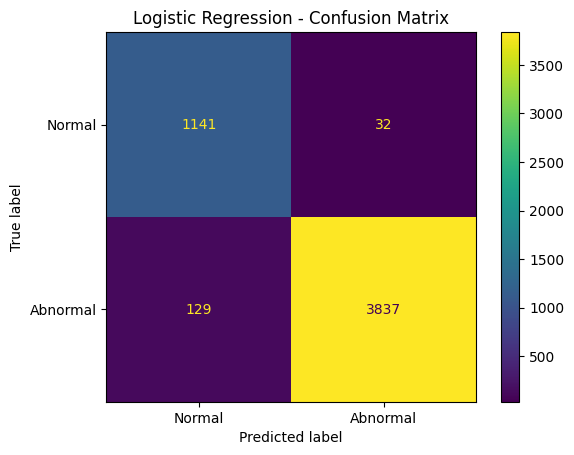

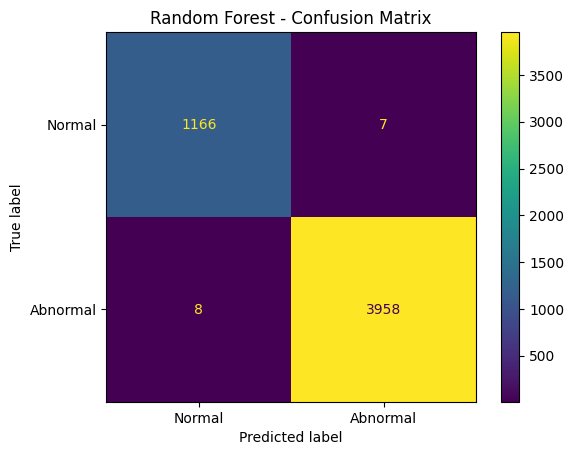

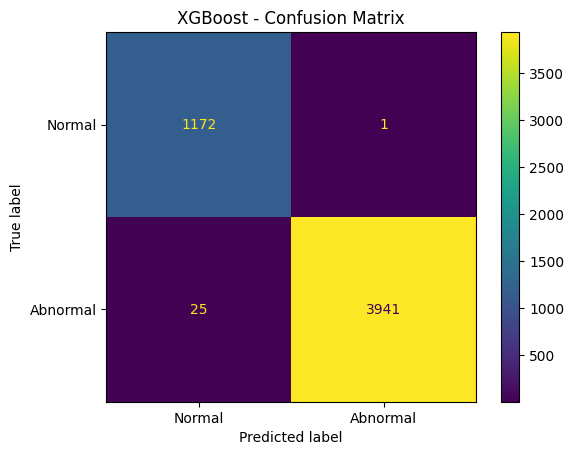

In [145]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, pipe in fitted_models.items():

    if name == "XGBoost":
        y_true = y_test_xgb
        pred = pipe.predict(X_test)
        labels = [0, 1]
        display_labels = ["Normal", "Abnormal"]

    else:
        y_true = y_test
        pred = pipe.predict(X_test)
        labels = ["Normal", "Abnormal"]
        display_labels = ["Normal", "Abnormal"]

    cm = confusion_matrix(
        y_true,
        pred,
        labels=labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )

    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


## Classification Report

In [146]:
from sklearn.metrics import classification_report

for name, pipe in fitted_models.items():

    pred = pipe.predict(X_test)

    if name == "XGBoost":
        print(f"\n{name}")
        print(classification_report(
            y_test_xgb,
            pred,
            target_names=["Normal", "Abnormal"]
        ))
    else:
        print(f"\n{name}")
        print(classification_report(
            y_test,
            pred
        ))


Logistic Regression
              precision    recall  f1-score   support

    Abnormal       0.99      0.97      0.98      3966
      Normal       0.90      0.97      0.93      1173

    accuracy                           0.97      5139
   macro avg       0.95      0.97      0.96      5139
weighted avg       0.97      0.97      0.97      5139


Random Forest
              precision    recall  f1-score   support

    Abnormal       1.00      1.00      1.00      3966
      Normal       0.99      0.99      0.99      1173

    accuracy                           1.00      5139
   macro avg       1.00      1.00      1.00      5139
weighted avg       1.00      1.00      1.00      5139


XGBoost
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      1173
    Abnormal       1.00      0.99      1.00      3966

    accuracy                           0.99      5139
   macro avg       0.99      1.00      0.99      5139
weighted avg       1.00      

## StratifiedGroupKFold

In [147]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [121]:
y_encoded = y.map({
    "Normal": 0,
    "Abnormal": 1
})

In [122]:
cv_results = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X,
        y_encoded,
        groups=groups,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),

        "F1 Std": scores["test_f1"].std(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(6)

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,F1 Std,ROC-AUC Std
0,Logistic Regression,0.966756,0.990736,0.966042,0.978231,0.995801,0.000946,0.000725
1,Random Forest,0.997530,0.998984,0.997823,0.998403,0.999583,0.000627,0.000321
2,XGBoost,0.994665,0.999541,0.993563,0.996543,0.999803,0.000672,0.000080


## ROC Curve

In [148]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, roc_auc_score

fig = go.Figure()

for name, pipe in fitted_models.items():

    if name == "XGBoost":
        y_true = y_test_xgb
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_true = (y_test == "Abnormal").astype(int)
        classes = pipe.named_steps["model"].classes_
        abnormal_index = list(classes).index("Abnormal")
        y_prob = pipe.predict_proba(X_test)[:, abnormal_index]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    fig.add_trace(
        go.Scatter(
            x=fpr,
            y=tpr,
            mode="lines",
            name=f"{name} — AUC = {auc:.3f}",
            line=dict(width=3)
        )
    )

# خط الـ Random Classifier
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Random Classifier",
        line=dict(
            dash="dash",
            width=2
        )
    )
)

fig.update_layout(
    title=dict(
        text="ROC Curve — Model Comparison",
        x=0.5,
        font=dict(size=22)
    ),
    xaxis=dict(
        title="False Positive Rate",
        range=[0, 1],
        showgrid=True,
        gridcolor="lightgray"
    ),
    yaxis=dict(
        title="True Positive Rate",
        range=[0, 1],
        showgrid=True,
        gridcolor="lightgray"
    ),
    width=900,
    height=650,
    template="plotly_white",
    legend=dict(
        title="Models",
        x=0.60,
        y=0.05,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="lightgray",
        borderwidth=1
    ),
    margin=dict(l=80, r=40, t=90, b=80)
)

fig.show()

## Final Comparison

In [149]:
fig = px.bar(
    comparison_df,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    text_auto=".3f",
    title="Model Performance Comparison",
    color_discrete_sequence=[
        "#1E3A8A",
        "#2563EB",
        "#10B981",
        "#059669",
        "#064E3B"
    ]
)

fig.update_yaxes(range=[0.9, 1.0])

fig.show()

In [150]:
final_comparison = results_df.merge(
    cv_results_df[
        [
            "Model",
            "F1 Mean",
            "ROC-AUC Mean",
            "F1 Std",
            "ROC-AUC Std"
        ]
    ],
    on="Model"
)

display(final_comparison.round(6))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,F1 Mean,ROC-AUC Mean,F1 Std,ROC-AUC Std
0,Logistic Regression,0.968671,0.991729,0.967474,0.979451,0.996763,0.978231,0.995801,0.000946,0.000725
1,Random Forest,0.997081,0.998235,0.997983,0.998109,0.999947,0.998403,0.999583,0.000627,0.000321
2,XGBoost,0.994941,0.999746,0.993696,0.996712,0.999889,0.996543,0.999803,0.000672,0.000080


## Save Model

In [151]:
model_package = {
    "model": fitted_models["Random Forest"],
    "features": features,
    "target": target,
    "positive_class": "Abnormal",
    "model_name": "Random Forest"
}

joblib.dump(
    model_package,
    "vital_signs_risk_model.joblib"
)

print("Model package saved successfully!")

Model package saved successfully!


In [152]:
model_package = joblib.load(
    "vital_signs_risk_model.joblib"
)

model = model_package["model"]
features = model_package["features"]

print("Model:", model_package["model_name"])
print("Features:", features)

Model: Random Forest
Features: ['Heart_Rate', 'Respiratory_Rate', 'SpO2', 'Temperature']


In [153]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Prediction:", prediction)

Prediction: ['Normal']
